Github repository is here: https://github.com/ong8181/DASC3240

# PCA and others – Assignments

## Datasets
- Original paper: Abbas et al. (2019) _Ecological Indicators_ (https://doi.org/10.1016/j.ecolind.2019.105524)
- Study site data (edited): https://github.com/ong8181/DASC3240/blob/main/data/Abbas_2019_TableS4_ed1.csv
- Tree community data (edited): https://github.com/ong8181/DASC3240/blob/main/data/Abbas_2019_TableS4_ed2.csv

## References
- `sklearn.decomposition.PCA`: https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html#examples-using-sklearn-decomposition-pca
- `sklearn.manifold.MDS`: https://scikit-learn.org/stable/modules/generated/sklearn.manifold.MDS.html
- `sklearn.manifold.TSNE`: https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html

# Assignments
## Tree community data in Hong Kong
Go to https://github.com/ong8181/DASC3240/blob/main/data/ and download `Abbas_2019_TableS4_ed1.csv` and `Abbas_2019_TableS4_ed2.csv`.
- `Abbas_2019_TableS4_ed1.csv` includes the plot information.
- `Abbas_2019_TableS4_ed2.csv` includes dominant tree species data in the 28 forest plots.

1. Calculate the total abundance of the dominant tree species in each forest plot, and visualize the relationship between the total abundance and forest age. You should use `AGE_MEDIAN` column in the `Abbas_2019_TableS4_ed1.csv` file as a forest age index.
2. Visualize the dominant tree species compositions using PCA, NMDS, and t-SNE. For visualization, you must use different colors for different forest age groups.

[**Optional task**] Discuss the effects of forest age (`AGE_MEDIAN`) on the tree species compositions based on your visualization in Tasks 1 and 2.
  
<font color="darkred">Please remember to add appropriate axis labels (and units, if appropriate).</font>

# Declaration
<font color="darkred">Please answer the following questions.</font>  
Do you use AI-based assistant tool(s) (such as ChatGPT or Copilot) to complete the assignments?
- [ ] Yes
- [ ] No

If "Yes", please specify which task(s) you used the tool(s):
```
XXXX
```

## 1. Calculate the total abundance of the dominant tree species in each forest plot, and visualize the relationship between the total abundance and forest age. 

- You should use `AGE_MEDIAN` column in the `Abbas_2019_TableS4_ed1.csv` file as a forest age index.
- You can calculate **the sum of each column** in `Abbas_2019_TableS4_ed2.csv` to calculate the total abundance of the dominant tree species in each plot.
- You will combine the data from two dataframes, so please check if the column names of `Abbas_2019_TableS4_ed2.csv` and the row names (indices) of `Abbas_2019_TableS4_ed1.csv` match (by using Python script, not by visual inspection!).
- To visualize the relationship, "Jitterplot + Boxplot" or "Beeswarmplot + Boxplot" is recommended. Barplot is **NOT** recommended.

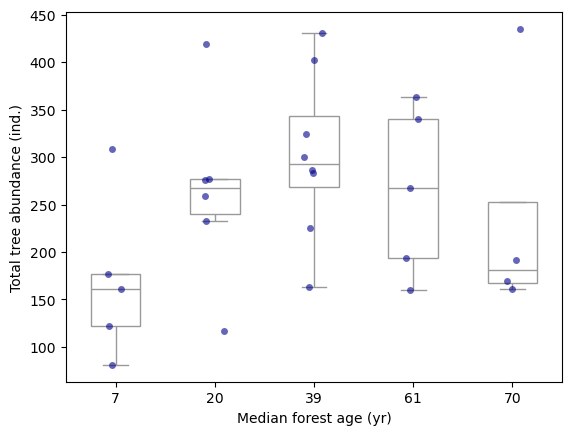

In [1]:
### Your Python code is here
### XXXXX

# Load libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
d_site = pd.read_csv("data/Abbas_2019_TableS4_ed1.csv", index_col = 0)
d_tree = pd.read_csv("data/Abbas_2019_TableS4_ed2.csv", index_col = 0)

# !!! An important step to check the column and row names !!! #
# Check if [the column names of d_tree] == [the row names of d_site]
# If this is False, you will assign the total abundance of a study plot to another study plot. 
all(d_site.index == d_tree.columns)

# Calculate the total tree abundance (only dominant species included in d_tree),
# and add the values to d_site
d_site = d_site.assign(total_abundance = d_tree.sum())
## Make sure that the "AGE_MEDIAN" is a categorical data
d_site["AGE_MEDIAN"] = d_site["AGE_MEDIAN"].astype("category")

# Visualize the relationship between the total tree abundance and forest age
fig, ax = plt.subplots()
## Create boxplot
sns.boxplot(data = d_site, x = "AGE_MEDIAN", y = "total_abundance",
            showfliers = False, width = 0.5, color = "white")
## Create jitterplot
sns.stripplot(data = d_site, x = "AGE_MEDIAN", y = "total_abundance",
            alpha = 0.6, color = "darkblue", jitter = True)
## Edit axis labels
ax.set_ylabel("Total tree abundance (ind.)")
ax.set_xlabel("Median forest age (yr)")
plt.show()

# 2. Visualize the dominant tree species compositions using PCA, NMDS, and t-SNE.

There are a number of points you should consider:

- For visualization, you must use different colors for different forest age groups. Use of different marker styles for different groups is also a good idea.
- Set random seeds if your analysis includes random process(es).
- Before applying dimension reduction functions (e.g., `PCA()`), please make sure that <font color="darkred">**rows represent samples (= forest plots) and columns represent tree species**</font>. You have to transpose the data frame (In `Abbas_2019_TableS4_ed2.csv`, columns represent samples and rows represent tree species).
- Usually we should consider whether we must perform the data preprocessing before applying dimension reduction techniques (e.g., standardization). In this assignment, please convert your data compositional using the following code `df = df.div(df.sum(axis = 0), axis = 1)` (`df` represents the name of your pandas dataframe. You should change it depending on your object name). This means that, in this assignment, we are interested in tree community compositions, not abundances.
- In t-SNE, you might get error massages regarding `perplexity`. This option controls the balance between preserving local and global structure in the data. It represents the number of nearest neighbors that each point is allowed to consider when calculating the probability distribution of its neighbors. You may use `perplexity = 15` in this assignment. 
- You will generate three plots. Please place the three plots in one large figure as in the example in the lecture PDF.

In [2]:
### Your Python code is here
### XXXXX

# Load libraries
from sklearn.decomposition import PCA

# Standardize the data
#ds = pd.DataFrame(StandardScaler().fit_transform(d_tree.transpose()))

# Calculate the relative abundance (%, compositional data)
d_tree_rel = d_tree.div(d_tree.sum(axis = 0), axis = 1)
ds = d_tree_rel.transpose() # Transpose so that each point indicate each study site

# PCA
pca = PCA()
pca_df = pd.DataFrame(pca.fit_transform(ds))
# Rename columns
pca_df = pca_df.rename(columns = {i: f'PC{i+1}' for i in range(len(pca_df.columns))})
# Add site information (forest age)
pca_df2 = pd.concat([pca_df, d_site["AGE_MEDIAN"].reset_index()], axis = 1)

In [3]:
# NMDS
from sklearn.manifold import MDS, TSNE
from sklearn.metrics import pairwise_distances

# Seed for consistency
#np.random.seed(1234)

# Calculate the distance matrix (here we use "manhattan" distance)
distance_matrix = pairwise_distances(ds, metric = "braycurtis")

# Perform PCoA
nmds = MDS(n_components = 2, dissimilarity = "precomputed", metric = False, random_state = 1234)
nmds_result = nmds.fit_transform(distance_matrix)

# Store the results as pd.DataFrame
nmds_df = pd.DataFrame(nmds_result, columns=["Axis1", "Axis2"])

# Add site information (forest age)
nmds_df2 = pd.concat([nmds_df, d_site["AGE_MEDIAN"].reset_index()], axis = 1)

/Users/ushio/miniconda3/lib/python3.11/site-packages/sklearn/manifold/_mds.py:299: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.
  warnings.warn(


In [4]:
# t-SNE
from sklearn.manifold import TSNE

# Seed for consistency
np.random.seed(1234)

# Perform t-SNE
tsne = TSNE(n_components = 2, perplexity = 15, random_state = 1234)
tsne_result = tsne.fit_transform(ds)

# Store the results as pd.DataFrame
tsne_df = pd.DataFrame(tsne_result, columns=["Axis1", "Axis2"])

# Add site information
tsne_df2 = pd.concat([tsne_df, d_site["AGE_MEDIAN"].reset_index()], axis = 1)

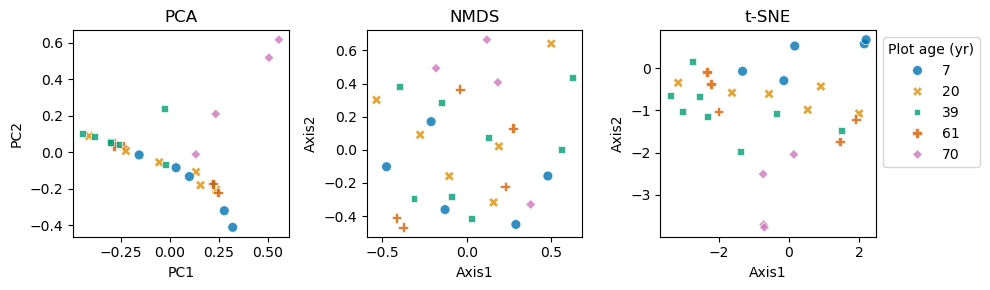

In [5]:
# Visualize the all results
## Prepare the figure and axis objects
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize = (10, 3))

## PCA plot
sns.scatterplot(x = "PC1", y = "PC2", data = pca_df2, hue = "AGE_MEDIAN", ax = ax1,
                legend = False, palette = "colorblind", style = "AGE_MEDIAN", s = 50, alpha = 0.8)
ax1.set_title("PCA")
## NMDS plot
sns.scatterplot(x = "Axis1", y = "Axis2", data = nmds_df2, hue = "AGE_MEDIAN", ax = ax2,
                legend = False, palette = "colorblind", style = "AGE_MEDIAN", s = 50, alpha = 0.8)
ax2.set_title("NMDS")
## tSNE plot
sns.scatterplot(x = "Axis1", y = "Axis2", data = tsne_df2, hue = "AGE_MEDIAN", ax = ax3,
                palette = "colorblind", style = "AGE_MEDIAN", s = 50, alpha = 0.8)
plt.legend(loc="upper left", bbox_to_anchor=(1,1), title = "Plot age (yr)")
ax3.set_title("t-SNE")
## Layout
plt.tight_layout()
## Show figure
plt.show()

## [Optional task] Discuss the effects of forest age (AGE_MEDIAN) on the tree species compositions based on your visualization in Tasks 1 and 2.

Your answer is here.  
XXXXX